In [1]:
import pandas as pd
import gzip
from io import StringIO

def load_geo_series_matrix(path):
    with gzip.open(path, 'rt') as f:
        lines = f.readlines()

    start, end = None, None
    for i, line in enumerate(lines):
        if line.startswith("!series_matrix_table_begin"):
            start = i + 1
        elif line.startswith("!series_matrix_table_end"):
            end = i
            break

    data = ''.join(lines[start:end])
    df = pd.read_csv(StringIO(data), sep="\t", index_col=0)
    return df



In [2]:
path = "/workspaces/Reasearch_Genomic/GSE18838_series_matrix.txt.gz.1"

df = load_geo_series_matrix(path)

print("Original shape:", df.shape)


Original shape: (17881, 28)


In [3]:
X = df.T
print("After transpose:", X.shape)


After transpose: (28, 17881)


In [4]:
import numpy as np

y = np.zeros(X.shape[0])
y[: X.shape[0] // 2] = 1   # first half = class 1


In [5]:
# Force numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Replace NaN / inf
X = X.fillna(0)


In [6]:
print(X.dtypes.unique())


[dtype('float64')]


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)


(28, 17881)


In [8]:
from sklearn.linear_model import LogisticRegression

lasso = LogisticRegression(
    penalty="l1",
    solver="saga",
    max_iter=5000,
    C=1.0
)

lasso.fit(X_scaled, y)


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [9]:
import numpy as np

coef = lasso.coef_[0]
importance = np.abs(coef)

genes = X.columns.to_numpy()

lasso_results = pd.DataFrame({
    "Gene": genes,
    "Coefficient": coef,
    "Importance": importance
})


In [10]:
top_32 = (
    lasso_results[lasso_results["Importance"] > 0]
    .sort_values(by="Importance", ascending=False)
    .head(32)
)

top_32


,Gene,Coefficient,Importance
2638,2569649,-0.159449,0.159449
11207,3474815,-0.128838,0.128838
14690,3811339,-0.128806,0.128806
5013,2845417,0.116033,0.116033
13984,3744410,-0.113198,0.113198
6621,3022409,-0.111859,0.111859
1020,2400655,-0.110772,0.110772
14366,3770328,-0.100431,0.100431
10426,3413067,-0.091844,0.091844
16735,3937967,0.086790,0.086790


In [11]:
top_32.to_csv("GSE18838_Top32_LASSO.csv", index=False)
print("Saved: GSE18838_Top32_LASSO.csv")


Saved: GSE18838_Top32_LASSO.csv


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape, X_val.shape)


(22, 17881) (6, 17881)


In [13]:
%pip install tensorflow



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [14]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam


2026-02-12 17:10:03.081980: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-12 17:10:03.130916: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-12 17:10:05.323256: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


In [15]:
model = Sequential([
    Dense(128, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(64, activation="relu"),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()


/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-02-12 17:10:06.338770: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │     2,288,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,297,217 (8.76 MB)

 Trainable params: 2,297,217 (8.76 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 64)             │     1,144,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,146,561 (4.37 MB)

 Trainable params: 1,146,561 (4.37 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dropout(0.3),

    Dense(32, activation="relu"),
    Dropout(0.3),

    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.summary()

/usr/local/python/3.12.1/lib/python3.12/site-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │     1,144,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,146,561 (4.37 MB)

 Trainable params: 1,146,561 (4.37 MB)

 Non-trainable params: 0 (0.00 B)

In [18]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_val, y_val),
    verbose=1
)


Epoch 1/50


2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 176ms/step - accuracy: 0.5000 - loss: 1.2003 - val_accuracy: 0.6667 - val_loss: 0.7585
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.5000 - loss: 2.2872 - val_accuracy: 0.6667 - val_loss: 0.6466
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.7273 - loss: 1.6128 - val_accuracy: 0.6667 - val_loss: 1.1437
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6364 - loss: 1.6359 - val_accuracy: 0.6667 - val_loss: 1.7084
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7273 - loss: 2.5792 - val_accuracy: 0.6667 - val_loss: 2.2771
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step - accuracy: 0.6364 - loss: 4.4835 - val_accuracy: 0.5000 - val_loss: 2.9628
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.7273 - loss: 1.2751 - val_accuracy: 0.5000 - val_loss: 3.1534
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.7727 - loss: 2.5276 - val_accuracy: 0.5000 - val_loss: 3.3041
Epoch 9/50

In [19]:
loss, accuracy = model.evaluate(X_val, y_val, verbose=0)

print(f"Validation Accuracy: {accuracy:.4f}")
print(f"Validation Loss: {loss:.4f}")


Validation Accuracy: 0.6667
Validation Loss: 14.1699


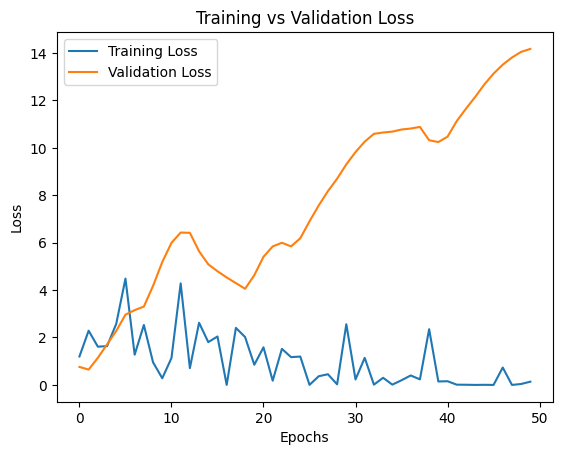

In [20]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()


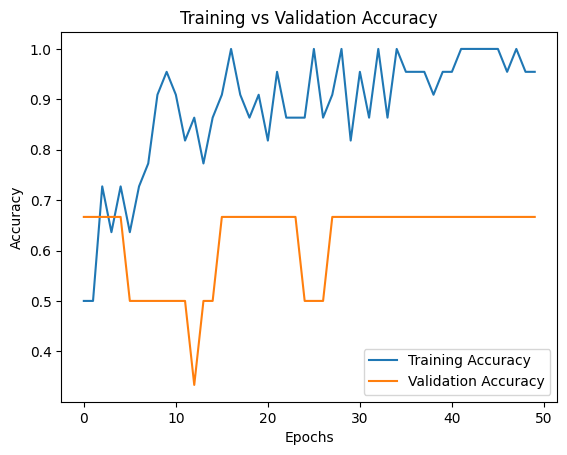

In [21]:
plt.figure()
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.show()


In [23]:
from sklearn.metrics import f1_score

y_pred_binary = model.predict(X_val) > 0.5
f1 = f1_score(y_val, y_pred_binary)

print(f"F1 Score: {f1:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
F1 Score: 0.7500


In [24]:
from sklearn.metrics import recall_score

recall = recall_score(y_val, y_pred_binary)
print(f"Recall: {recall:.4f}")

Recall: 1.0000


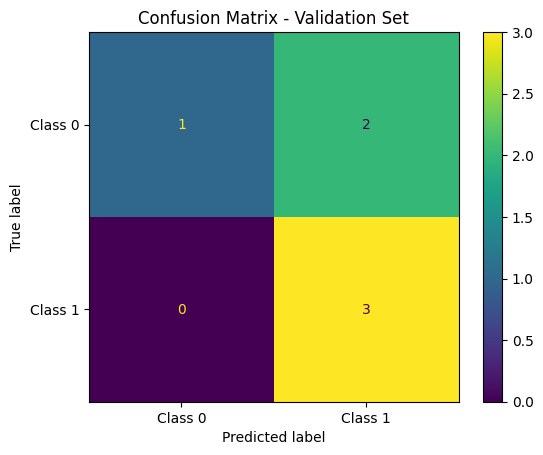

Confusion Matrix:
[[1 2]
 [0 3]]


In [25]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Compute confusion matrix
cm = confusion_matrix(y_val, y_pred_binary)

# Plot confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
disp.plot()
plt.title("Confusion Matrix - Validation Set")
plt.show()

print("Confusion Matrix:")
print(cm)

In [26]:
from tensorflow.keras.callbacks import EarlyStopping

# Define early stopping callback with minimum validation loss criteria
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# Retrain the model with early stopping
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

# Save the model
model.save("GSE18838_model_with_early_stopping.h5")
print("Model saved: GSE18838_model_with_early_stopping.h5")

Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step - accuracy: 0.9545 - loss: 0.0770 - val_accuracy: 0.6667 - val_loss: 14.0527
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9545 - loss: 0.9984 - val_accuracy: 0.5000 - val_loss: 13.8862
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9545 - loss: 0.0599 - val_accuracy: 0.5000 - val_loss: 13.7473
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - accuracy: 1.0000 - loss: 6.1514e-05 - val_accuracy: 0.5000 - val_loss: 13.7217
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 1.0000 - loss: 0.0062 - val_accuracy: 0.5000 - val_loss: 13.6578
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.9545 - loss: 0.2365 - val_accuracy: 0.5000 - val_loss: 13.4859
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 1.0000 - loss: 0.0138 - val_accuracy: 0.5000 - val_loss: 13.3347
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9545 - loss: 0.3437 - val_accuracy: 0.5000 - val_lo

Model saved: GSE18838_model_with_early_stopping.h5


In [27]:
path = "/workspaces/Reasearch_Genomic/GSE57475_series_matrix.txt.gz.1"

df = load_geo_series_matrix(path)
print("Original shape:", df.shape)


Original shape: (48766, 142)


In [28]:
X = df.T
print("After transpose:", X.shape)


After transpose: (142, 48766)


In [29]:
import numpy as np

y = np.zeros(X.shape[0])
y[: X.shape[0] // 2] = 1


In [30]:
X = X.apply(pd.to_numeric, errors="coerce")
X = X.fillna(0)

print(X.dtypes.unique())


[dtype('float64')]


In [31]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(X_scaled.shape)


(142, 48766)


In [32]:
from sklearn.linear_model import LogisticRegression

lasso = LogisticRegression(
    penalty="l1",
    solver="saga",
    max_iter=5000,
    C=1.0
)

lasso.fit(X_scaled, y)


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1160: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'l1'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass`

In [33]:
import pandas as pd
import numpy as np

coef = lasso.coef_[0]
importance = np.abs(coef)
genes = X.columns.to_numpy()

lasso_df = pd.DataFrame({
    "Gene": genes,
    "Coefficient": coef,
    "Importance": importance
})


In [34]:
top_32 = (
    lasso_df[lasso_df["Importance"] > 0]
    .sort_values(by="Importance", ascending=False)
    .head(32)
)

top_32


,Gene,Coefficient,Importance
47132,ILMN_2359029,0.061848,0.061848
10453,ILMN_1702197,0.056198,0.056198
610,ILMN_1653712,0.054488,0.054488
30805,ILMN_1834190,0.052684,0.052684
28419,ILMN_1813833,-0.052179,0.052179
13997,ILMN_1722738,-0.052139,0.052139
47986,ILMN_2390310,0.049816,0.049816
15496,ILMN_1731720,-0.048421,0.048421
4642,ILMN_1672165,0.048089,0.048089
9515,ILMN_1696974,0.047845,0.047845


In [35]:
top_32.to_csv("GSE57475_Top32_LASSO.csv", index=False)
print("Saved: GSE57475_Top32_LASSO.csv")


Saved: GSE57475_Top32_LASSO.csv


In [54]:
selected_genes = top_32["Gene"].values
X_lasso = X[selected_genes]


In [36]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X_lasso,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


NameError: name 'X_lasso' is not defined

In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)


In [ ]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, log_loss


In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    batch_size=16,
    learning_rate_init=0.001,
    max_iter=1,
    warm_start=True,
    random_state=42
)


In [ ]:
epochs = 50

train_losses, val_losses = [], []
train_acc, val_acc = [], []

for _ in range(epochs):
    mlp.fit(X_train_scaled, y_train)

    y_train_pred = mlp.predict(X_train_scaled)
    y_val_pred = mlp.predict(X_val_scaled)

    y_train_prob = mlp.predict_proba(X_train_scaled)
    y_val_prob = mlp.predict_proba(X_val_scaled)

    train_acc.append(accuracy_score(y_train, y_train_pred))
    val_acc.append(accuracy_score(y_val, y_val_pred))

    train_losses.append(log_loss(y_train, y_train_prob))
    val_losses.append(log_loss(y_val, y_val_prob))


/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (1) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/python/3.12.1/lib/python3

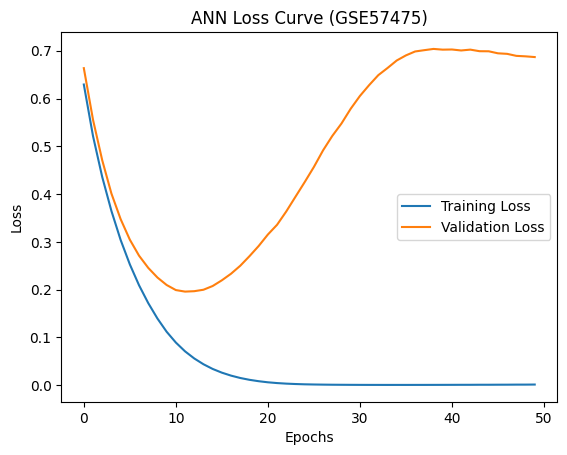

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("ANN Loss Curve (GSE57475)")
plt.legend()
plt.show()


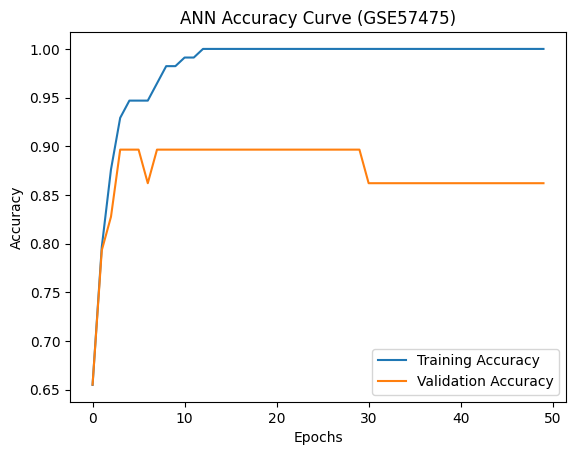

In [ ]:
plt.figure()
plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("ANN Accuracy Curve (GSE57475)")
plt.legend()
plt.show()


In [38]:
from sklearn.metrics import f1_score

f1 = f1_score(y_val, y_pred_binary)

print(f"F1 Score: {f1:.4f}")

F1 Score: 0.7500


In [39]:
# Ensure 1D binary predictions and compute recall
if 'y_pred_binary' in globals():
    y_pred_bin = np.ravel(y_pred_binary).astype(int)
elif 'y_pred' in globals():
    y_pred_bin = (np.ravel(y_pred) > 0.5).astype(int)
else:
    raise NameError("No predictions found (y_pred or y_pred_binary).")

y_true = np.ravel(y_val).astype(int)

recall = recall_score(y_true, y_pred_bin)
print(f"Recall: {recall:.4f}")

Recall: 1.0000


Confusion Matrix:
 [[1 2]
 [0 3]]


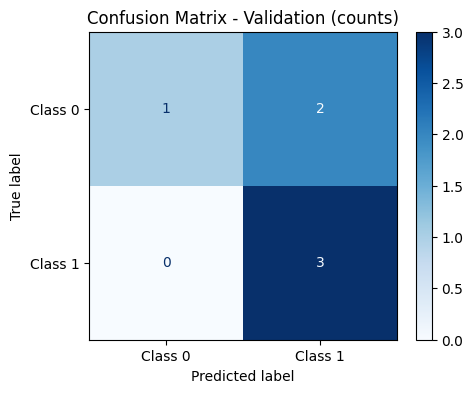

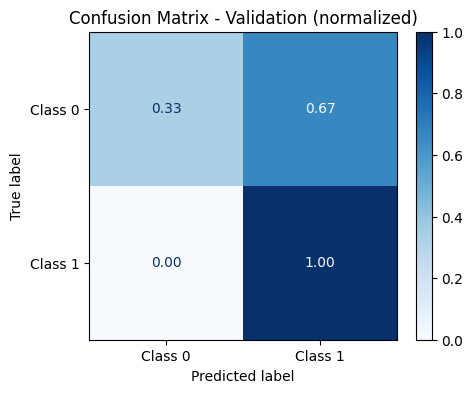

In [40]:
# Compute/ensure 1D integer arrays for true and predicted labels
y_true = np.ravel(y_val).astype(int)

if 'y_pred_binary' in globals():
    y_pred_int = np.ravel(y_pred_binary).astype(int)
elif 'y_pred' in globals():
    y_pred_int = (np.ravel(y_pred) > 0.5).astype(int)
elif 'y_pred_bin' in globals():
    y_pred_int = np.ravel(y_pred_bin).astype(int)
else:
    raise NameError("No predictions found (y_pred, y_pred_binary, or y_pred_bin).")

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_int)
print("Confusion Matrix:\n", cm)

# Plot confusion matrix (counts)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Class 0", "Class 1"])
fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, cmap=plt.cm.Blues, colorbar=True)
ax.set_title("Confusion Matrix - Validation (counts)")
plt.show()

# Plot normalized confusion matrix (percent)
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)
fig, ax = plt.subplots(figsize=(5, 4))
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=["Class 0", "Class 1"])
disp_norm.plot(ax=ax, cmap=plt.cm.Blues, values_format=".2f", colorbar=True)
ax.set_title("Confusion Matrix - Validation (normalized)")
plt.show()

In [41]:
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.callbacks import EarlyStopping

# Save best model based on minimum validation loss
checkpoint = ModelCheckpoint(
    "GSE57475_best_model.h5",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1
)

# Use existing early_stop if present, otherwise create one
try:
    callbacks = [early_stop, checkpoint]
except NameError:
    early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True, verbose=1)
    callbacks = [early_stop, checkpoint]

history = model.fit(
    X_train,
    y_train,
    epochs=100,
    batch_size=16,
    validation_data=(X_val, y_val),
    callbacks=callbacks,
    verbose=1
)

print("Best model saved to: GSE57475_best_model.h5")

Epoch 1/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.9375 - loss: 1.1619
Epoch 1: val_loss improved from None to 13.56034, saving model to GSE57475_best_model.h5



Epoch 1: finished saving model to GSE57475_best_model.h5
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step - accuracy: 0.9545 - loss: 0.8450 - val_accuracy: 0.5000 - val_loss: 13.5603
Epoch 2/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 1.0000 - loss: 6.3266e-07
Epoch 2: val_loss did not improve from 13.56034
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step - accuracy: 1.0000 - loss: 4.6012e-07 - val_accuracy: 0.5000 - val_loss: 14.0477
Epoch 3/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 1.0000 - loss: 4.4958e-04
Epoch 3: val_loss did not improve from 13.56034
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step - accuracy: 1.0000 - loss: 3.2734e-04 - val_accuracy: 0.5000 - val_loss: 14.4831
Epoch 4/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 1.0000 - loss: 6.3201e-06
Epoch 4: val_loss did not improve from 13.56034
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - accuracy: 0.9545 - loss: 1.0859 - val_accuracy: 0.5000 - val_loss: 14.8724
Epoch 5/100
1/2 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 1.0